# Decison Tree


#### Note :

This notebook includes additional images, screenshots, diagrams, and explanatory notes in some sections to support my understanding of the concepts.

 I incorporated these materials as part of my learning process and to create useful study notes for future reference.

  The primary objective was to understand the concepts thoroughly while completing the assignment.

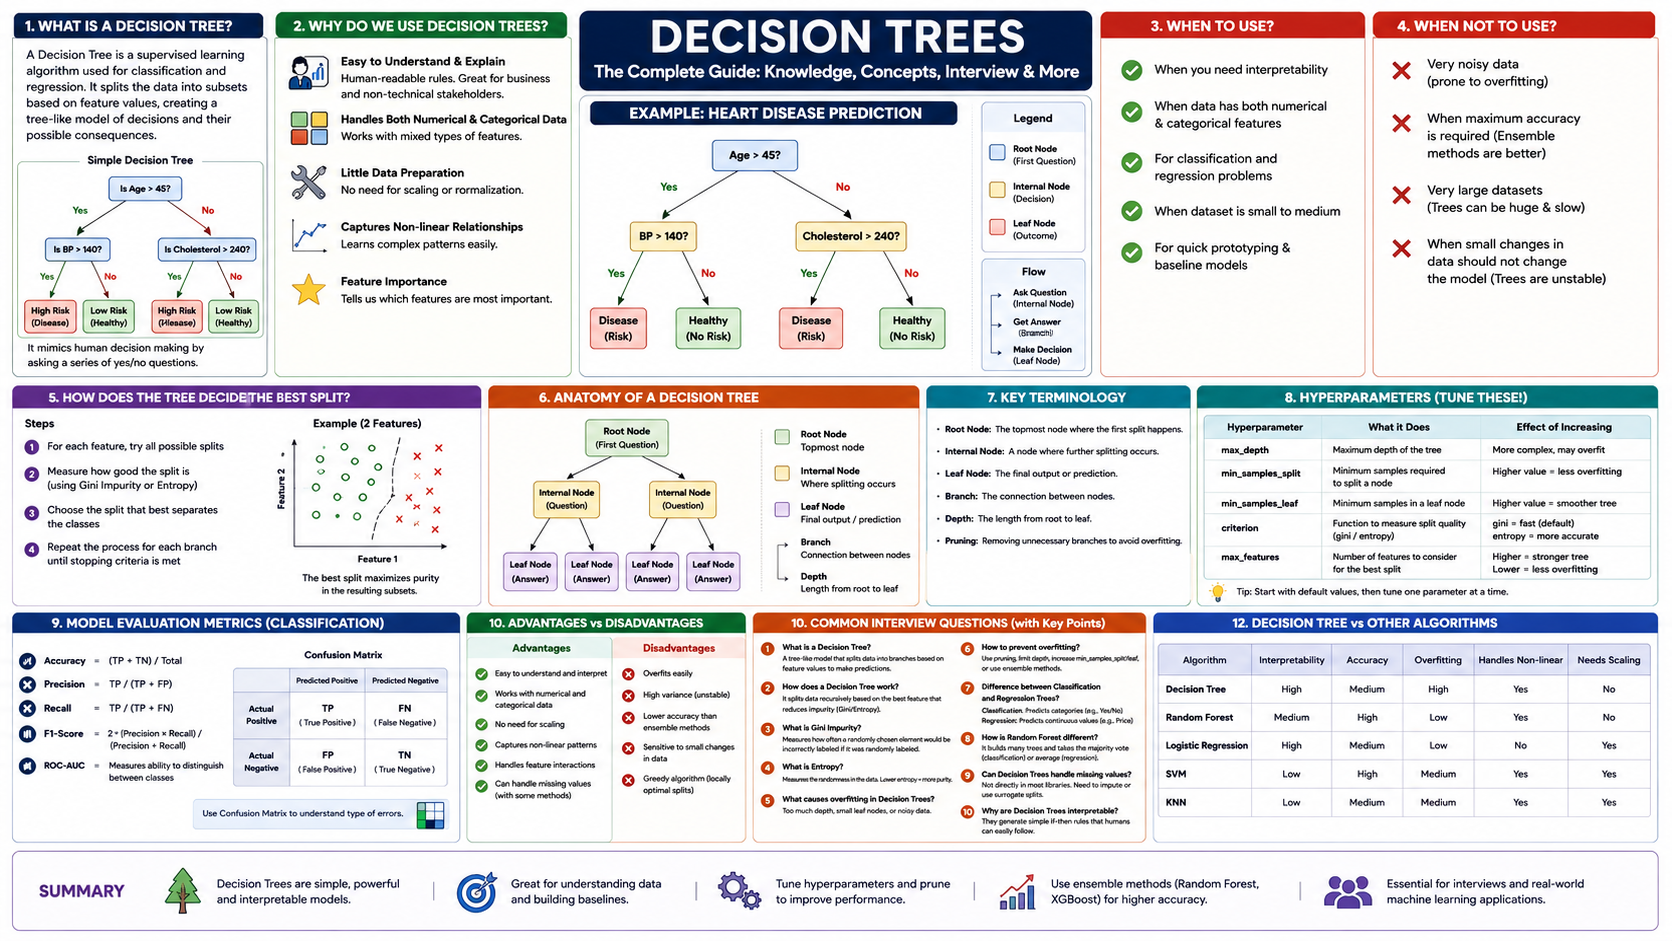

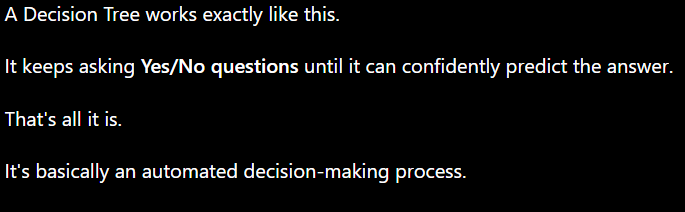

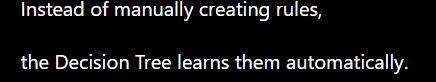

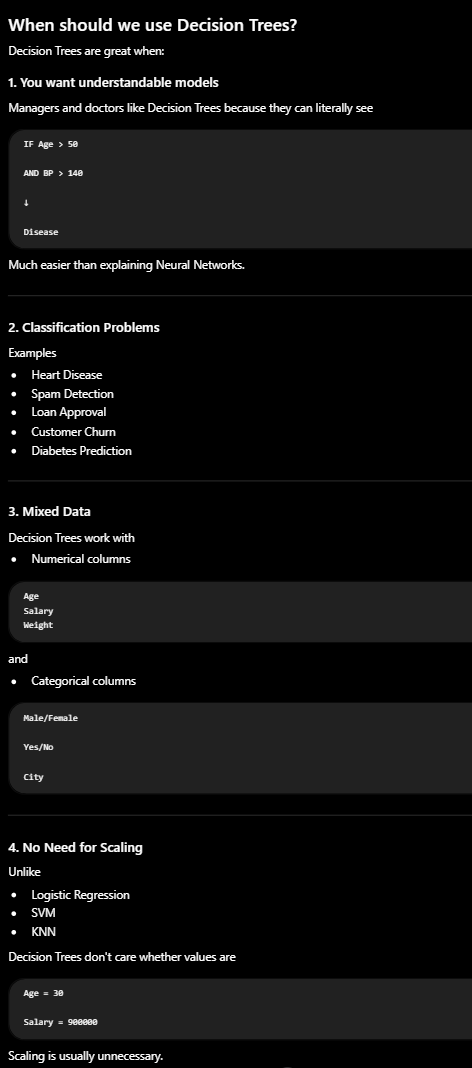

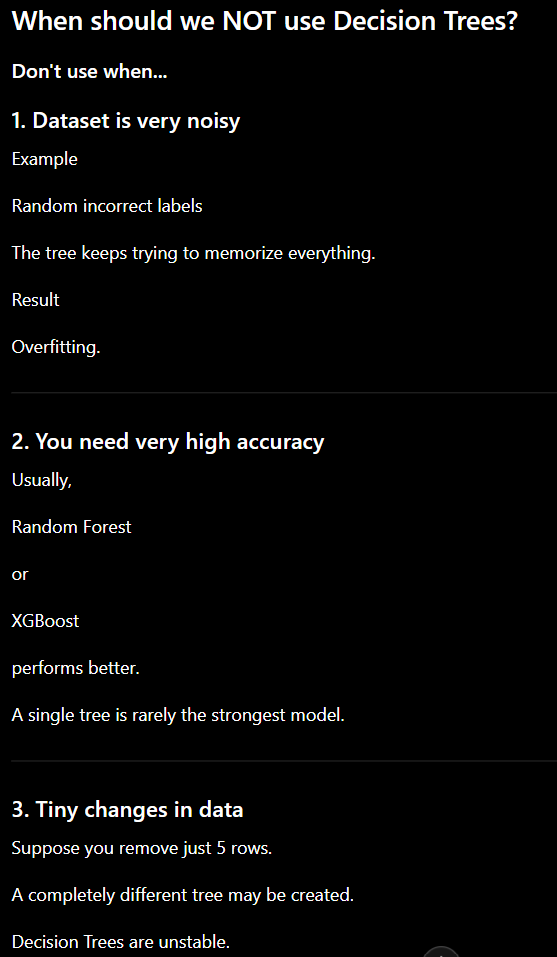

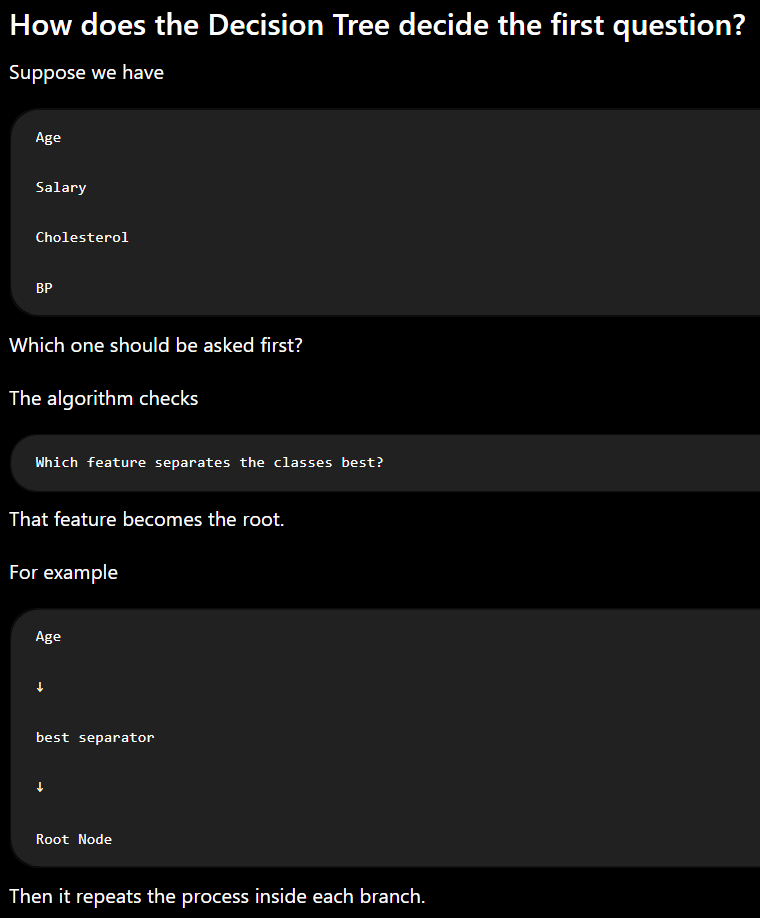

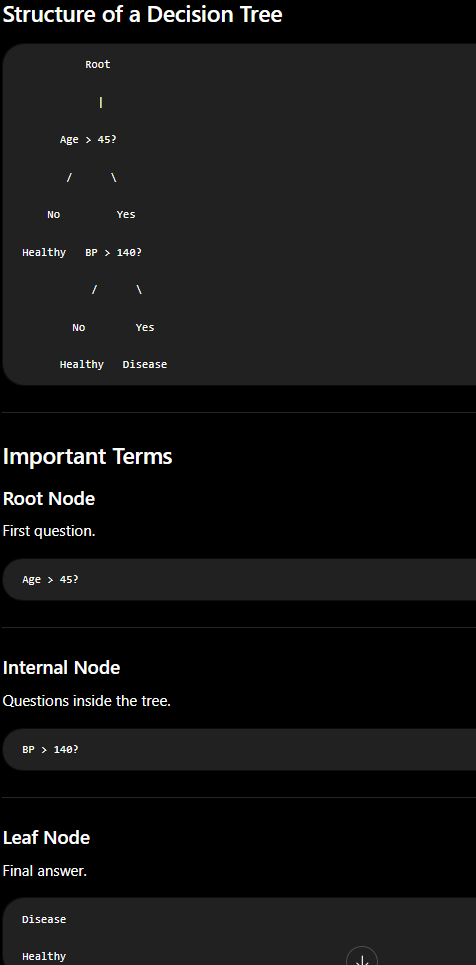

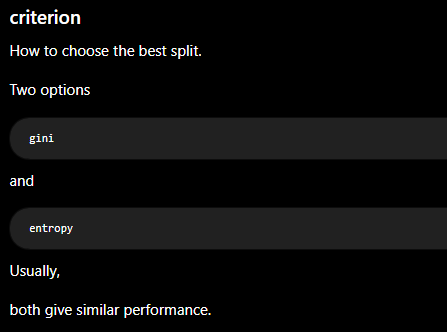

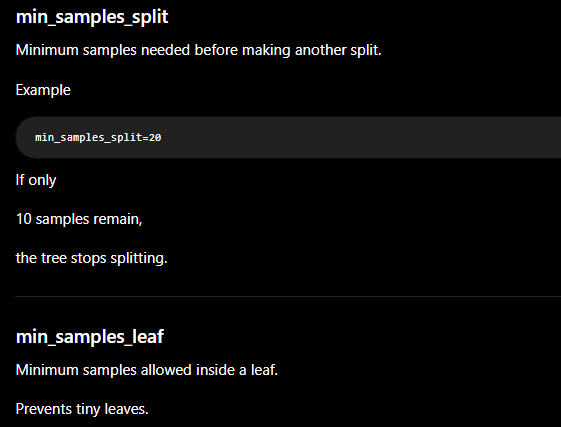

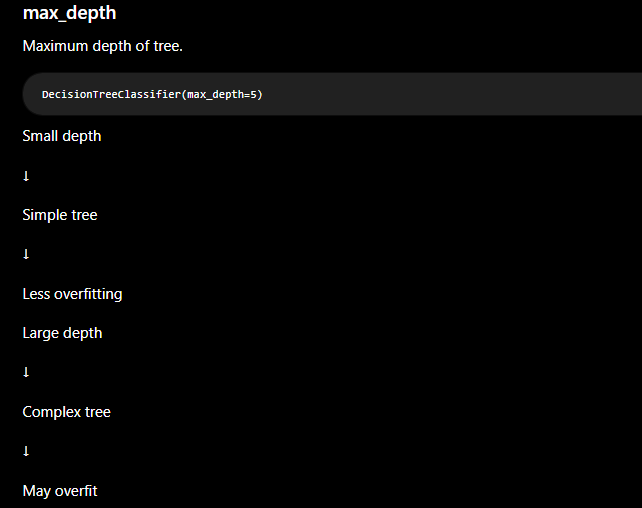

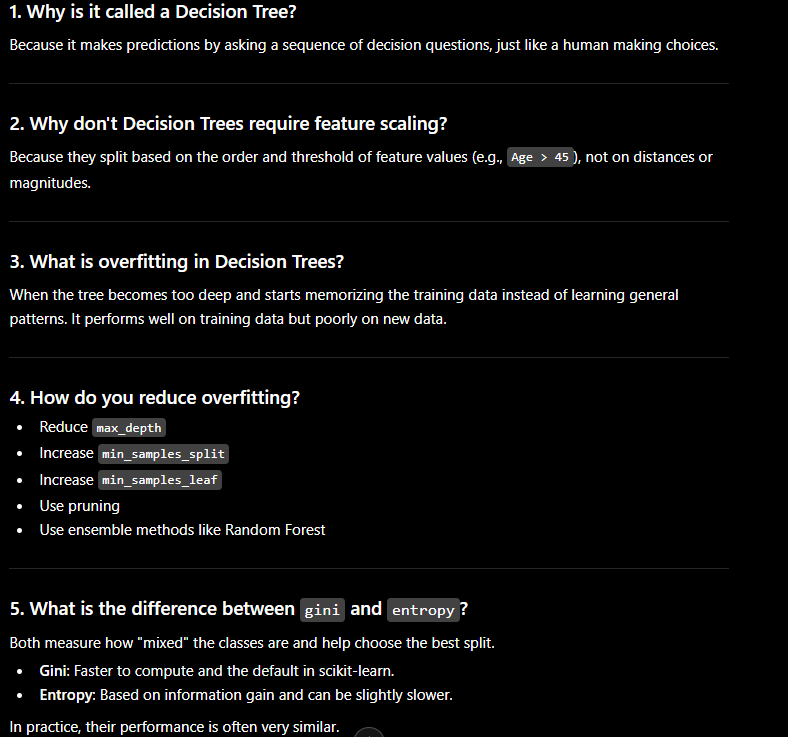

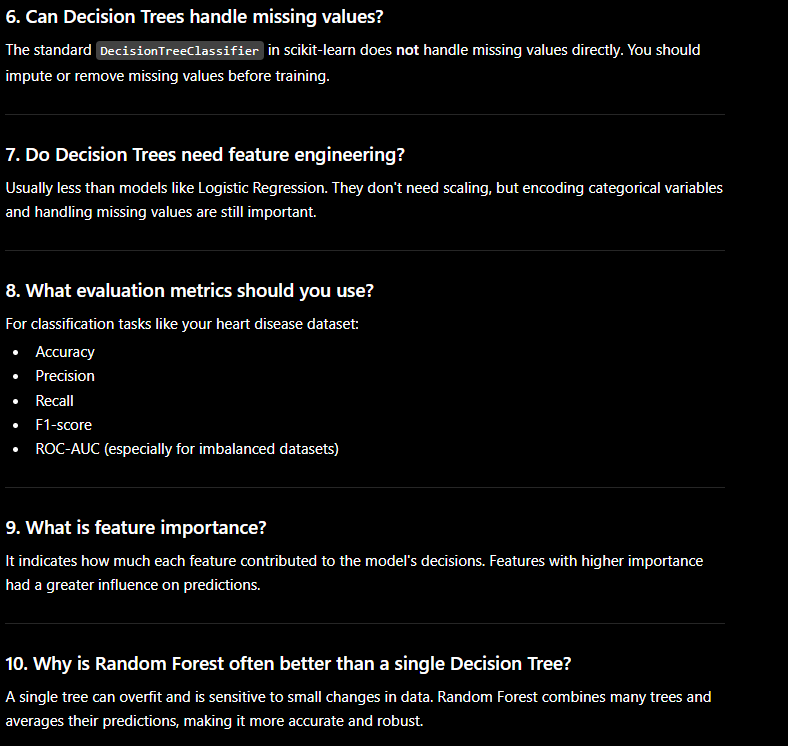

| Term               | Meaning                            | Interview Answer                                                   |
| ------------------ | ---------------------------------- | ------------------------------------------------------------------ |
| Root Node          | First node of the tree             | The initial split containing all training samples.                 |
| Parent Node        | Node that splits into children     | A node that produces one or more child nodes.                      |
| Child Node         | Node created after a split         | The result of splitting a parent node.                             |
| Leaf Node          | Final node                         | The node where prediction is made and no further splitting occurs. |
| Split              | Dividing data based on a condition | Separates data into more homogeneous groups.                       |
| Branch             | Connection between nodes           | Represents the outcome of a decision (True/False).                 |
| Depth              | Number of levels                   | Controls the complexity of the tree.                               |
| Entropy            | Measure of impurity                | Lower entropy means purer nodes.                                   |
| Gini Index         | Another impurity measure           | Lower Gini indicates better class separation.                      |
| Information Gain   | Reduction in entropy               | Measures how useful a split is.                                    |
| Samples            | Number of observations at a node   | Training records reaching that node.                               |
| Value              | Class distribution                 | Number of samples from each class at the node.                     |
| Class              | Predicted class                    | Majority class at the node.                                        |
| Feature Importance | Contribution of each feature       | Indicates how much each feature influenced predictions.            |
| Overfitting        | Learns noise                       | Performs well on training data but poorly on new data.             |
| Underfitting       | Too simple                         | Cannot capture important patterns.                                 |
| Hyperparameter     | User-defined parameter             | Controls model behavior before training.                           |
| Criterion          | Split metric                       | Gini or Entropy used to choose the best split.                     |


| Term           | Explanation                                    |
| -------------- | ---------------------------------------------- |
| Grid           | Collection of all hyperparameter combinations  |
| Search         | Testing every combination                      |
| CV             | Cross Validation                               |
| Fold           | One partition of the training data             |
| Estimator      | Model being optimized (DecisionTreeClassifier) |
| Param Grid     | Dictionary containing hyperparameters          |
| Best Score     | Highest average cross-validation accuracy      |
| Best Params    | Best hyperparameter combination                |
| Best Estimator | Final optimized model                          |


In [1]:
import numpy as np
import pandas as pd

In [2]:
# we have two sheets in excel one is metadata and another has acutal data we need to work on

excel_file = pd.ExcelFile("heart_disease.xlsx")

print(excel_file.sheet_names)

['Description', 'Heart_disease']


In [3]:
metadata = pd.read_excel("heart_disease.xlsx", sheet_name="Description")

metadata.head()

,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...


"Do I have enough data to make reliable conclusions?"

In [4]:
df = pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [5]:
df.shape

(908, 13)

An 80:20 train-test split would result in approximately:

726 training samples

182 testing samples

This is generally sufficient for a Decision Tree classifier.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


The dataset includes both

numerical variables (such as age, resting blood pressure, cholesterol, and maximum heart rate)

and

 categorical variables
(such as gender, chest pain type, ECG results, and thalassemia),

making it appropriate for classification tasks after preprocessing

In [7]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


Most patients belong to the middle-aged and older adult population, indicating that the dataset primarily focuses on age groups at higher risk of cardiovascular diseases

The average resting blood pressure lies within the range often associated with elevated cardiovascular risk.

However,

A value of 0 mmHg is medically impossible and likely represents missing or incorrectly recorded data.

This feature should be investigated further during data cleaning.

Several patients have cholesterol values recorded as 0, which is biologically unrealistic.

These values likely represent missing information rather than actual cholesterol levels and should be treated during preprocessing.

The maximum value of 603 suggests the presence of possible extreme observations that should be examined using box plots.

The feature heart rate shows a wide range of heart rates, indicating variation among patients and making it a potentially informative predictor for heart disease.

This feature old peak exhibits both missing values and a relatively wide range, indicating the need for data cleaning and further analysis of its distribution and potential outliers.

mean and median

Most numerical variables have mean values close to their median values.

Insight

This suggests that many features are reasonably centered, although some variables (such as cholesterol and oldpeak) may still contain skewness or outliers.

Histograms will confirm this during EDA.

standard deviation

Several variables show relatively large standard deviations.

Examples:

Cholesterol ≈ 112
Heart Rate ≈ 27
Blood Pressure ≈ 20
Insight

The data exhibits considerable variability among patients, suggesting that patient health conditions differ substantially across the dataset.



Potential outliers are expected in:

Cholesterol

Resting Blood Pressure

oldpeak

Maximum Heart Rate

Insight

These features should be visualized using box plots to determine whether extreme values are genuine observations or data-entry errors.

In [8]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62




The dataset is relatively clean since only one feature has missing values.
Approximately 6.8% of the values in the oldpeak column are missing:

908/
62
	​
×100 ≈ 6.8%

Since the missing percentage is low, these values can be handled using an imputation technique such as replacing them with the median or mean.

In [10]:
df['num'].value_counts()

,count
num,
0,399
1,265
2,109
3,107
4,28


In [11]:
df['num'].value_counts(normalize = True)* 100

,proportion
num,
0,43.942731
1,29.185022
2,12.004405
3,11.784141
4,3.083700


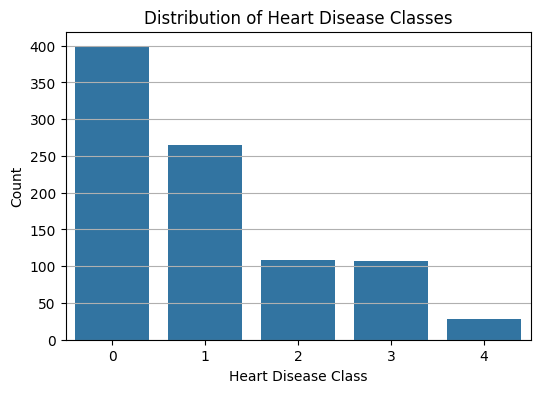

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(
    data = df ,
    x = 'num'
)
plt.title("Distribution of Heart Disease Classes")
plt.xlabel("Heart Disease Class")
plt.ylabel("Count")

plt.grid(axis = 'y')
plt.show()

The target variable contains five classes (0–4), confirming that this is a multiclass classification problem.

The dataset is imbalanced, as the number of patients varies considerably across classes.

The majority of patients belong to Class 0, while Class 4 has very few samples.
Because of this imbalance, relying only on accuracy may not provide a complete assessment of model performance.

Metrics such as Precision, Recall, and F1-score should also be considered.

Why are histograms useful before machine learning?

They help identify:

Missing or suspicious values

Outliers

Skewed distributions

Data quality issues

These observations guide preprocessing decisions and improve model reliability.

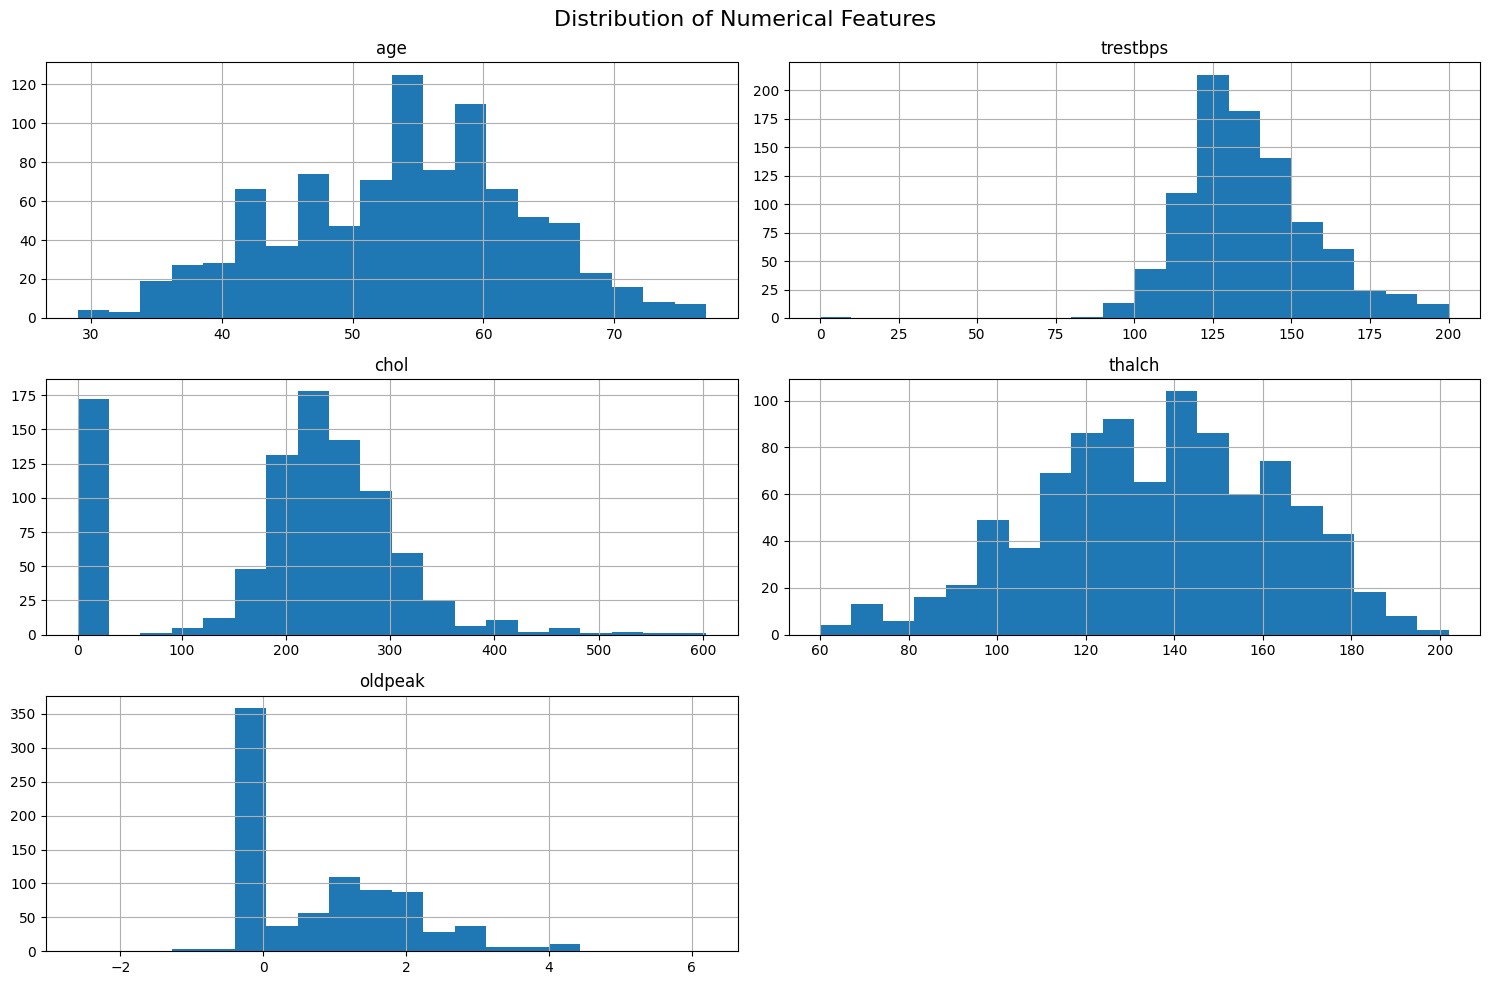

In [13]:
# Select numerical columns
numerical_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]

# Plot histograms
df[numerical_cols].hist( # similar to df.hist() where we get the hist plots of all the data
    figsize=(15, 10),
    bins=20,
    )

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

plt.tight_layout() automatically adjusts the spacing between subplots so that:

Titles don't overlap.

Axis labels remain visible.

Charts have proper spacing.

The figure looks neat and professional.

Without it, your graphs may look messy, especially when plotting multiple charts.

The histograms indicate that:
Age is approximately normally distributed.

Resting blood pressure follows a near-normal distribution but contains invalid zero values.

Cholesterol contains suspicious zero values and possible extreme outliers.
Maximum heart rate is well distributed.

Oldpeak is positively skewed and contains missing values.

In [14]:
categorical_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "thal"
    ]


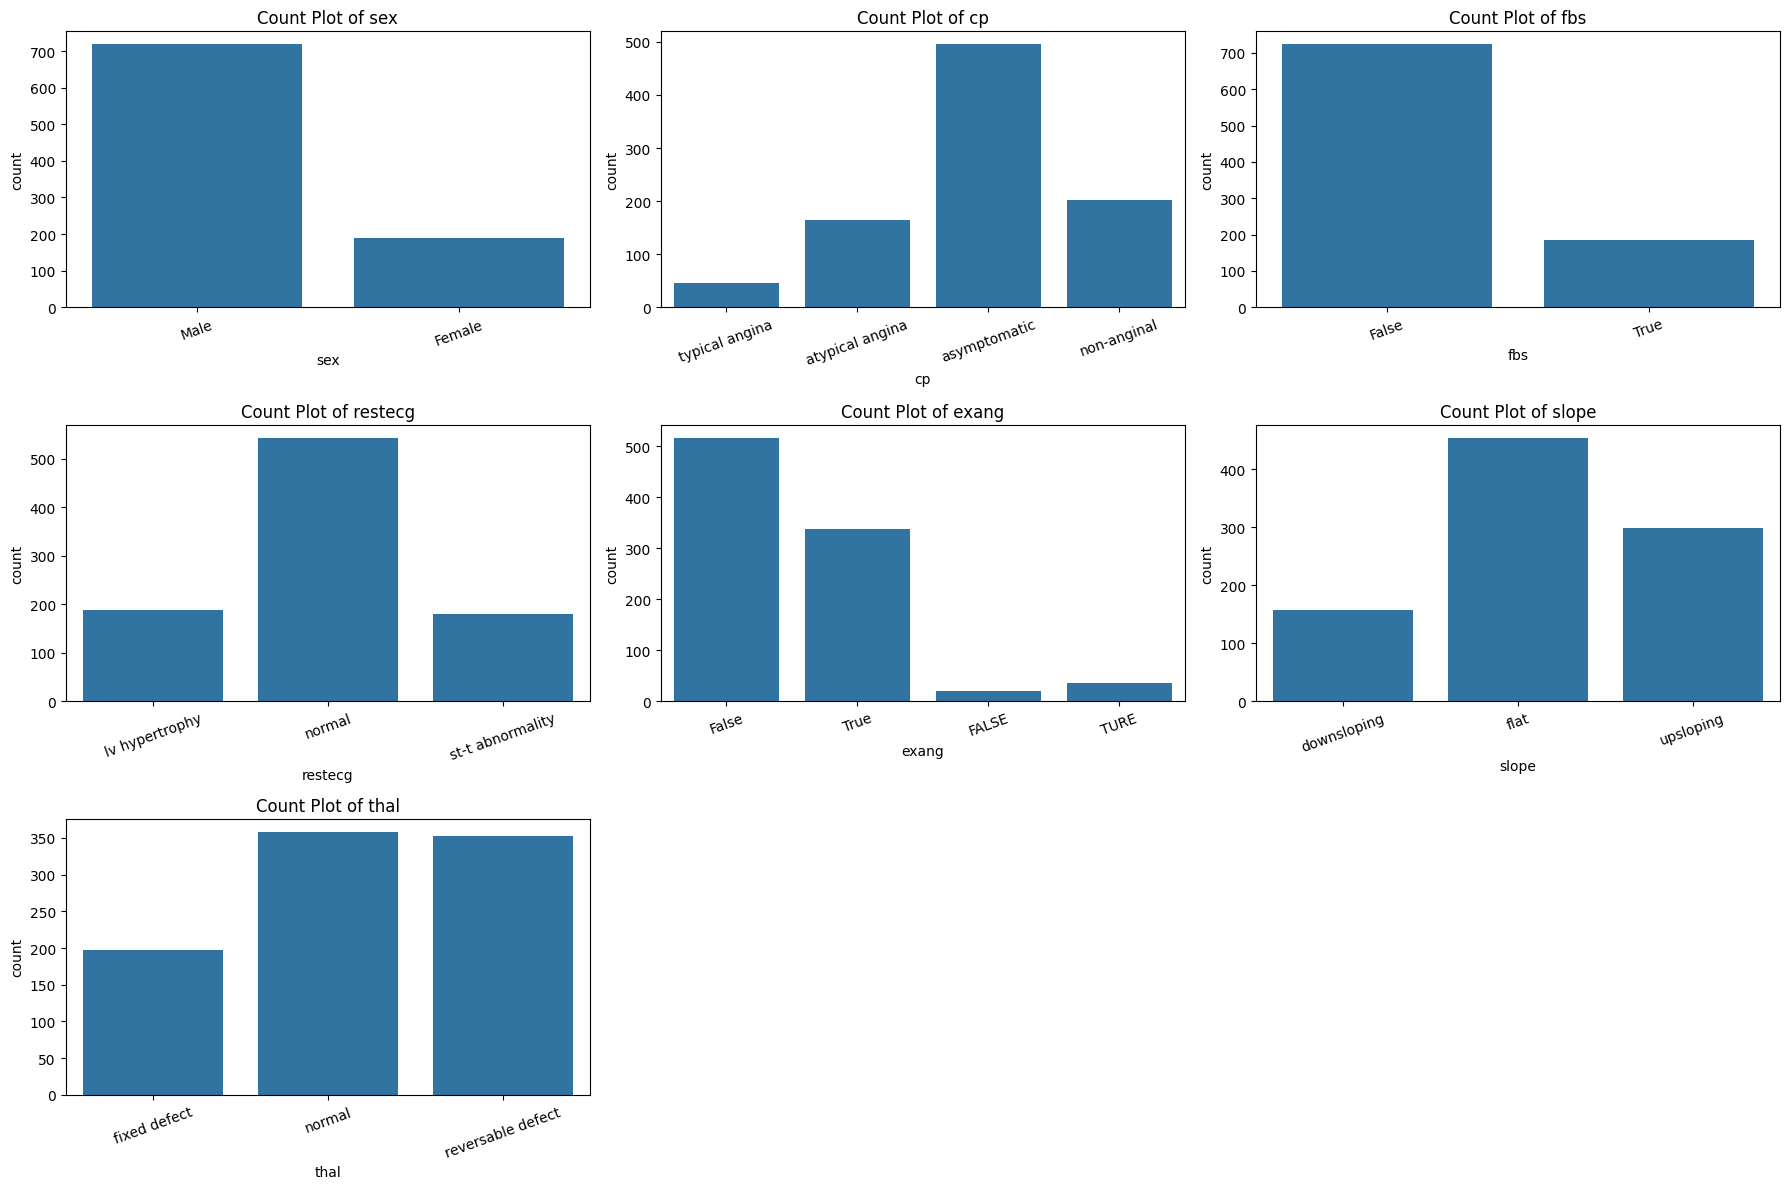

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)

    sns.countplot(
        x=col,
        data=df
        )

    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

Overall Categorical Feature Insights

The dataset contains several categorical predictors with varying distributions.
The dataset is male-dominated.

Asymptomatic chest pain is the most common chest pain category.

Most patients have normal ECG readings.

Elevated fasting blood sugar is relatively uncommon.

The exang column contains inconsistent category labels (True vs TRUE, False vs FALSE), indicating a data cleaning issue that should be corrected before model training.

The slope and thal features have reasonably distributed categories and are likely to be informative predictors.

In [16]:
# Select numerical columns
numerical_cols = [
    "age",
    "trestbps",
    "chol",
    "thalch",
    "oldpeak"
    ]

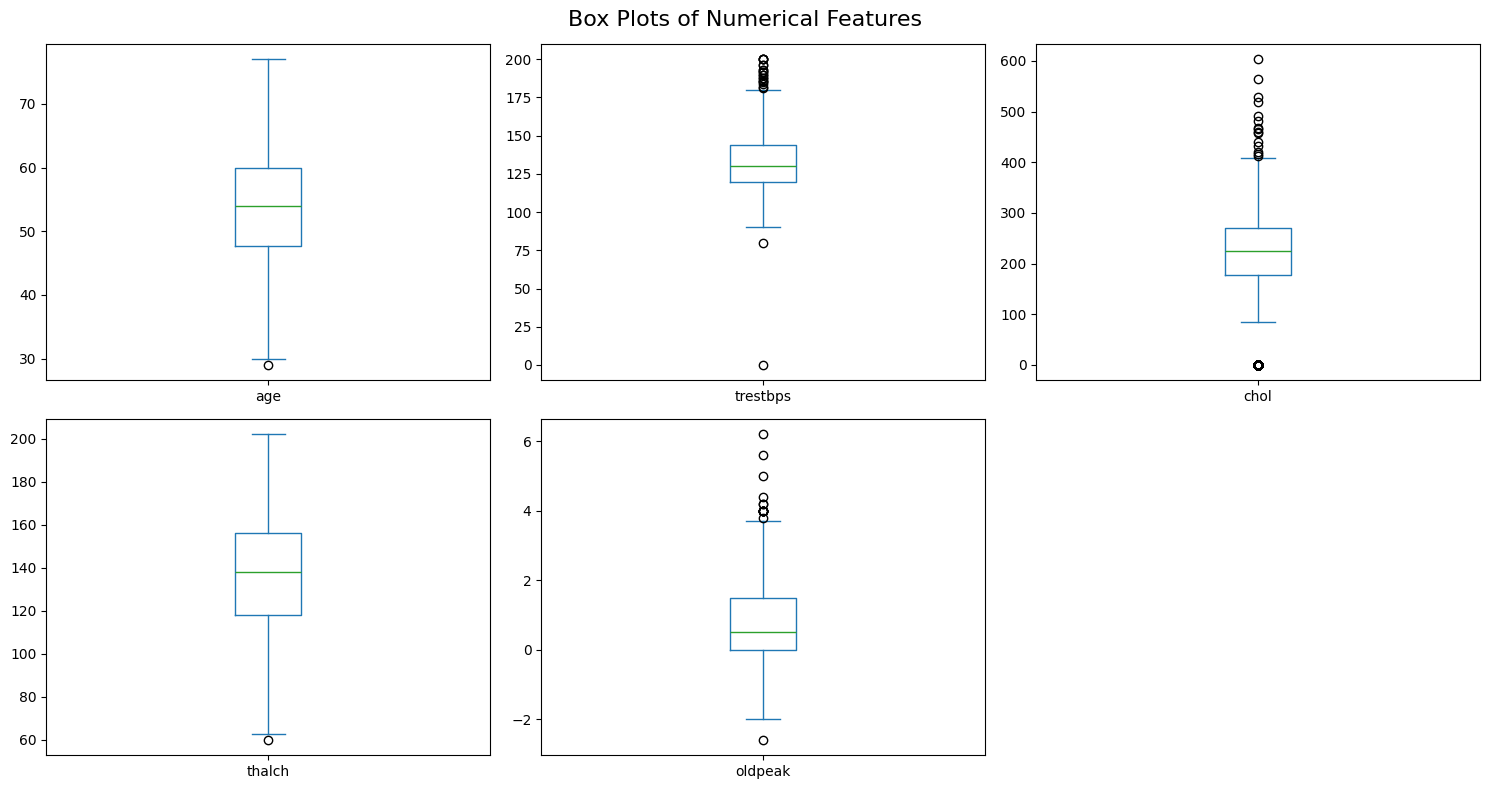

In [17]:

# Plot boxplots
df[numerical_cols].plot(
    kind="box",
    subplots=True,
    layout=(2,3),
    figsize=(15,8)
)

plt.suptitle("Box Plots of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

The box plots reveal that cholesterol and oldpeak contain the highest number of outliers, while age and maximum heart rate show relatively few.

Resting blood pressure includes an unrealistic value of 0, indicating a potential data quality issue.

Since Decision Trees are relatively robust to outliers, these values do not necessarily need to be removed, but invalid values and missing data should be addressed during preprocessing.

In [18]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=["int64", "float64"])

In [19]:

# Correlation matrix
corr_matrix = numerical_df.corr()
corr_matrix

,age,trestbps,chol,thalch,oldpeak,num
age,1.000000,0.253999,-0.099967,-0.328088,0.242662,0.326493
trestbps,0.253999,1.000000,0.117488,-0.133360,0.167131,0.137251
chol,-0.099967,0.117488,1.000000,0.197907,0.029898,-0.238813
thalch,-0.328088,-0.133360,0.197907,1.000000,-0.139598,-0.323058
oldpeak,0.242662,0.167131,0.029898,-0.139598,1.000000,0.437577
num,0.326493,0.137251,-0.238813,-0.323058,0.437577,1.000000


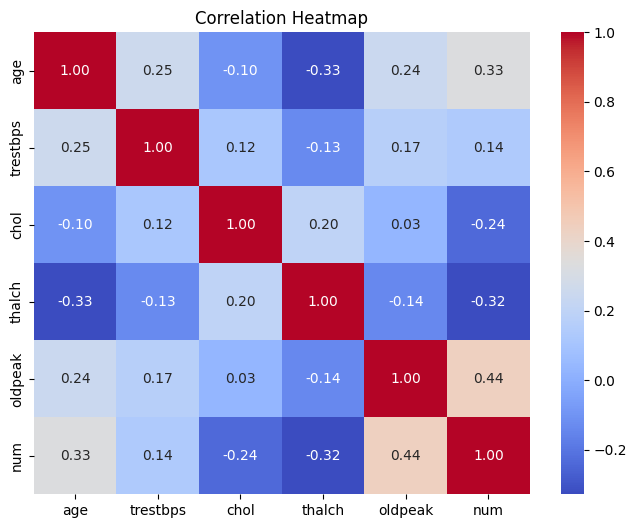

In [20]:

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap indicates that most numerical features have weak to moderate relationships with one another, suggesting the absence of strong multicollinearity.

 Among the features, oldpeak shows the strongest positive correlation with the target variable (num), while thalch exhibits a moderate negative correlation.

  Since no pair of predictor variables demonstrates a very high correlation (typically above ±0.8), all numerical features can be retained for Decision Tree modeling.

In [21]:
df.duplicated().sum() # checking the duplicate values

np.int64(1)

In [23]:
df = df.drop_duplicates().copy() # drop in the duplicate value

In [24]:
print(df.duplicated().sum()) # verifying the duplicate value

0


In [25]:
# Check missing values
df["oldpeak"].isnull().sum()

np.int64(62)

In [26]:
# Fill missing values with the median
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

In [27]:
# Verify
print(df["oldpeak"].isnull().sum())

0


In [28]:
print(df.shape) # after removing the duplicates we got the output as 907 rows

(907, 13)


In [29]:
df.loc[:, "trestbps"] = df["trestbps"].replace(0, np.nan)

df.loc[:, "trestbps"] = df["trestbps"].fillna(df["trestbps"].median())

/tmp/ipykernel_503/4145166956.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[145. 135. 140. 118. 110. 160. 130. 110. 140. 155. 170. 150. 125. 130.
 120. 130. 142. 120. 140. 100. 102. 130. 112. 160. 130. 112. 130. 118.
 120. 146. 138. 140. 140. 110. 120. 135. 134. 118. 122. 125. 130. 136.
 120. 130. 108. 130. 115. 112. 130. 150. 110. 100. 110. 104. 138. 138.
 120. 110. 110. 130. 128. 140. 106. 156. 112. 155. 130. 130. 160. 140.
 110. 130. 138. 120. 140. 150. 134. 110. 128. 138. 140. 102. 150. 120.
 120. 160. 130. 129. 160. 124. 130. 126. 140. 132. 108. 105. 138. 120.
 128. 120. 120. 135. 150. 150. 130. 130. 135. 105. 152. 120. 120. 130.
 138. 118. 150. 122. 124. 148. 140. 120. 140.  94. 112. 130. 140. 138.
 140. 120. 138. 128. 115. 122. 130. 118. 130. 120. 125. 180. 132. 120.
 140. 112. 130. 140. 110. 120. 140. 150. 134. 178. 120. 160. 120. 125.
 130. 120. 170. 115. 135. 120. 152. 128. 105. 140. 120. 108. 118.

In [30]:
# Replace invalid 0 values with NaN
df.loc[:, "chol"] = df["chol"].replace(0, np.nan)

# Fill missing values using the median
df.loc[:, "chol"] = df["chol"].fillna(df["chol"].median())

/tmp/ipykernel_503/526917604.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[233. 203. 192. 186. 201. 228. 276. 211. 260. 175. 237. 226. 273. 197.
 240. 250. 177. 211. 197. 248. 265. 303. 149. 234. 197. 160. 264. 242.
 302. 278. 220. 294. 394. 214. 219. 250. 271. 240. 213. 245. 214. 196.
 209. 234. 141. 245. 303. 340. 318. 243. 238. 222. 211. 208. 236. 243.
 178. 175. 265. 275. 208. 308. 223. 245. 204. 269. 256. 180. 360. 239.
 235. 262. 257. 295. 417. 212. 201. 254. 303. 234. 239. 318. 283. 244.
 295. 302. 315. 196. 201. 209. 269. 306. 211. 342. 267. 198. 223. 226.
 308. 215. 220. 304. 240. 247. 266. 204. 252. 204. 277. 325. 340. 246.
 175. 182. 168. 192. 255. 244. 226. 236. 195. 199. 250. 253. 235. 271.
 321. 157. 183. 205. 260. 222. 219. 210. 204. 269. 213. 325. 288. 354.
 221. 268. 233. 261. 240. 223. 216. 439. 254. 270. 240. 310.  nan 220.
 231. 258. 227. 564. 234. 193. 298. 263. 240. 313. 177. 233. 277. 

In [31]:
print((df["trestbps"] == 0).sum())
print((df["chol"] == 0).sum())

0
0


In [32]:
print(df['exang'].unique())

[False True 'FALSE' 'TURE']


In [33]:
df['exang'] = df['exang'].str.lower()
df['exang'].unique()

array([nan, 'false', 'ture'], dtype=object)

In [34]:
df["exang"] = df["exang"].replace("ture", "true")

In [35]:
df["exang"].unique()

array([nan, 'false', 'true'], dtype=object)

In [36]:
df["exang"] = df["exang"].fillna(df["exang"].mode()[0])

In [37]:
df["exang"].unique()

array(['true', 'false'], dtype=object)

In [38]:
df["exang"] = df["exang"].map({
    "false": 0,
    "true": 1 ,
})

In [39]:
df["exang"].unique()

array([1, 0])

In [40]:
# Convert boolean column to integers
df["fbs"] = df["fbs"].astype(int)

# One-Hot Encode categorical columns
df = pd.get_dummies(
    df,
    columns=["sex", "cp", "restecg", "exang", "slope", "thal"],
    drop_first=True
)

In [41]:
df.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_1,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,1,150,2.3,0,True,False,False,True,False,False,True,False,False,False,False
1,41,135.0,203.0,0,132,0.0,0,True,True,False,False,True,False,True,True,False,False,False
2,57,140.0,192.0,0,148,0.4,0,True,False,False,False,True,False,True,True,False,False,False
3,52,118.0,186.0,0,190,0.0,0,True,False,False,True,False,False,True,True,False,False,False
4,57,110.0,201.0,0,126,1.5,0,True,False,False,False,True,False,True,True,False,False,False


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 907 entries, 0 to 907
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       907 non-null    int64  
 1   trestbps                  907 non-null    float64
 2   chol                      907 non-null    float64
 3   fbs                       907 non-null    int64  
 4   thalch                    907 non-null    int64  
 5   oldpeak                   907 non-null    float64
 6   num                       907 non-null    int64  
 7   sex_Male                  907 non-null    bool   
 8   cp_atypical angina        907 non-null    bool   
 9   cp_non-anginal            907 non-null    bool   
 10  cp_typical angina         907 non-null    bool   
 11  restecg_normal            907 non-null    bool   
 12  restecg_st-t abnormality  907 non-null    bool   
 13  exang_1                   907 non-null    bool   
 14  slope_flat     

In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X = df.drop('num',axis = 1)

In [45]:
y = df['num']

In [46]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)

In [47]:
from sklearn.tree import DecisionTreeClassifier

In [48]:
model = DecisionTreeClassifier()

In [49]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [50]:
y_pred = model.predict(X_test)

In [51]:
print(y_pred[:10])

[1 1 0 0 1 1 1 0 1 1]


In [52]:
X_train.shape

(725, 17)

In [53]:
X_test.shape

(182, 17)

In [54]:
y_train.shape

(725,)

In [55]:
y_test.shape

(182,)

In [56]:
print(model)

DecisionTreeClassifier()


In [57]:
comparison = pd.DataFrame({
    'Actual' : y_test.values,
    'predicted': y_pred
})


In [58]:
comparison.head(10)

,Actual,predicted
0,3,1
1,1,1
2,0,0
3,2,0
4,3,1
5,3,1
6,1,1
7,0,0
8,4,1
9,1,1


In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.521978021978022


In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[62 13  6  7  1]
 [ 6 27 11  3  0]
 [ 2  9  5  3  1]
 [ 4  9  2  1  1]
 [ 3  3  1  2  0]]


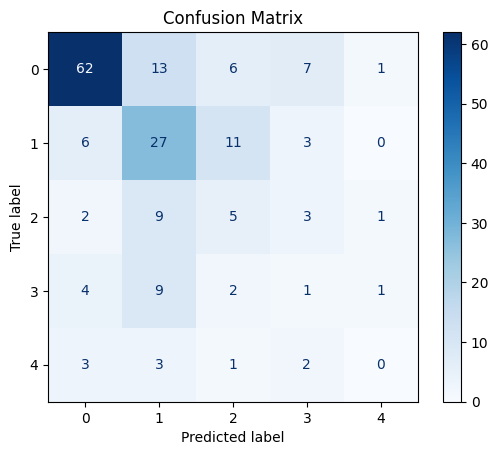

In [61]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [62]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.81      0.70      0.75        89
           1       0.44      0.57      0.50        47
           2       0.20      0.25      0.22        20
           3       0.06      0.06      0.06        17
           4       0.00      0.00      0.00         9

    accuracy                           0.52       182
   macro avg       0.30      0.32      0.31       182
weighted avg       0.54      0.52      0.52       182



The Decision Tree model achieved an overall accuracy of 50% on the test dataset.

 The model classified Class 0 effectively but showed weak performance for Classes 2, 3, and 4. The low macro average indicates that the model struggled to generalize across all classes, suggesting that further tuning is required to improve multiclass classification performance.

| Hyperparameter      | Purpose                                                       |
| ------------------- | ------------------------------------------------------------- |
| `criterion`         | Measures how the best split is selected (`gini` or `entropy`) |
| `max_depth`         | Limits how deep the tree can grow                             |
| `min_samples_split` | Minimum number of samples required to split a node            |
| `min_samples_leaf`  | Minimum number of samples that must remain in each leaf       |


In [63]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [3, 5, 7, 10, None]

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Max Depth = {depth}, Accuracy = {accuracy:.4f}")

Max Depth = 3, Accuracy = 0.5549
Max Depth = 5, Accuracy = 0.5330
Max Depth = 7, Accuracy = 0.5000
Max Depth = 10, Accuracy = 0.5440
Max Depth = None, Accuracy = 0.5330


Different values of max_depth were evaluated to control the complexity of the Decision Tree.

 Limiting the tree depth helps reduce overfitting and improves the model's ability to generalize to unseen data. The depth that produced the highest test accuracy was selected.

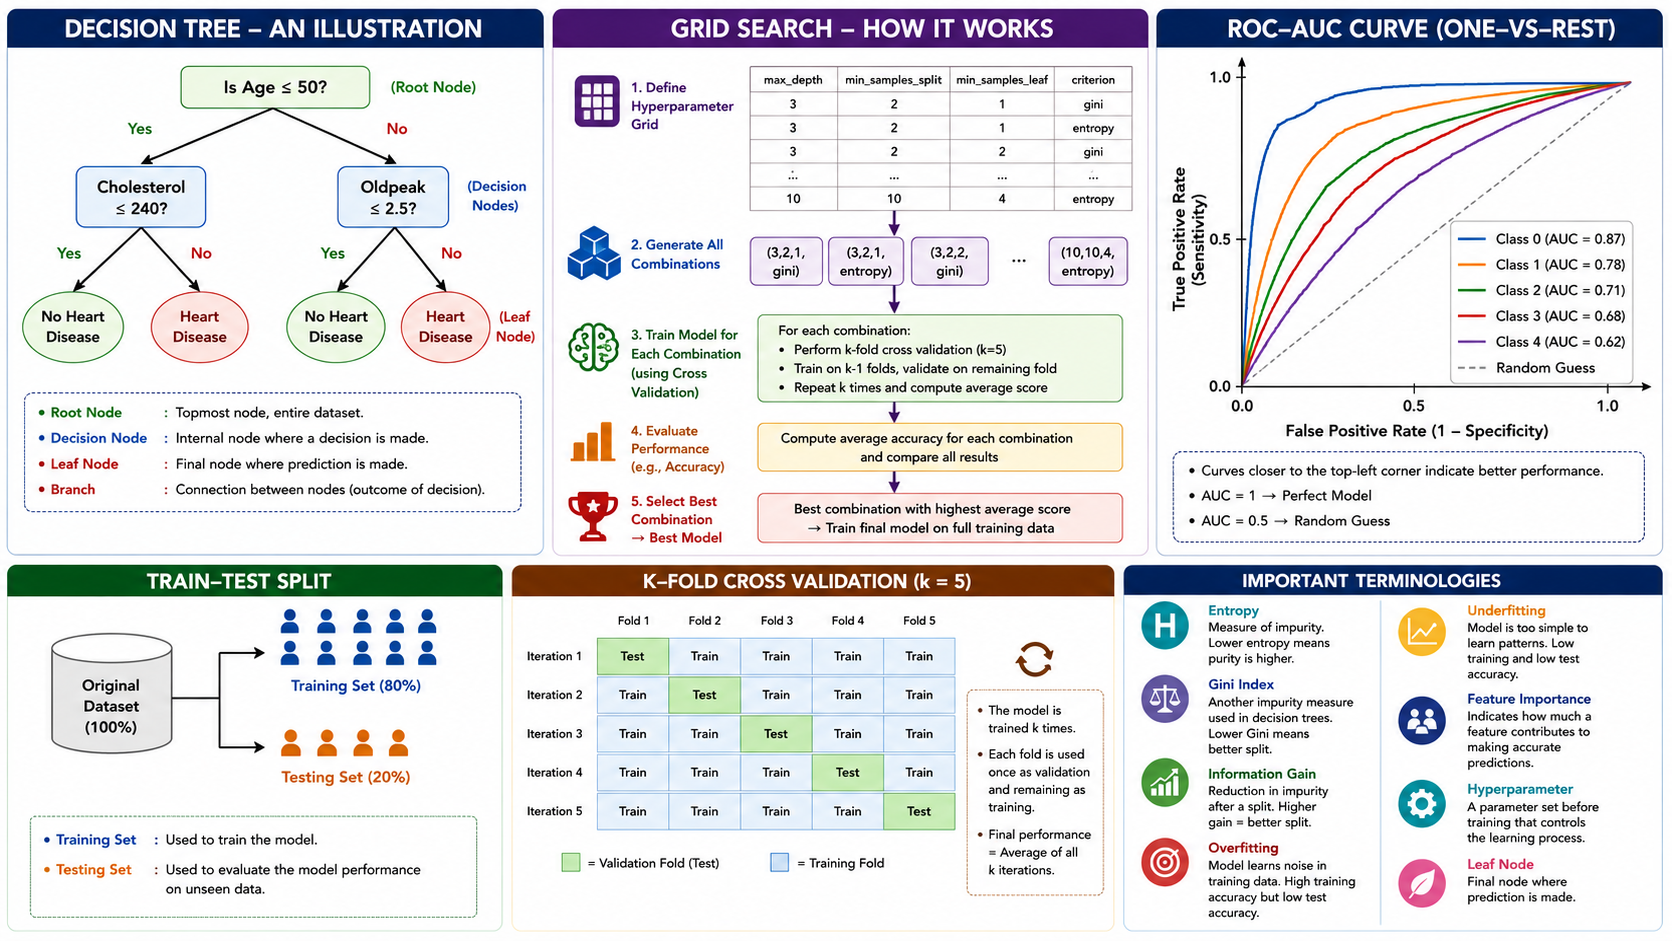

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train Grid Search
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [65]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [66]:
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.5117241379310344


In [67]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Test Accuracy: 0.5054945054945055
              precision    recall  f1-score   support

           0       0.77      0.65      0.71        89
           1       0.37      0.64      0.47        47
           2       0.15      0.10      0.12        20
           3       0.17      0.12      0.14        17
           4       0.00      0.00      0.00         9

    accuracy                           0.51       182
   macro avg       0.29      0.30      0.29       182
weighted avg       0.51      0.51      0.49       182



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation.

The optimal parameters were criterion='entropy', max_depth=7, min_samples_leaf=2, and min_samples_split=10.

The tuned model achieved a cross-validation accuracy of 51.17% and a test accuracy of 50.55%, indicating consistent performance on unseen data.

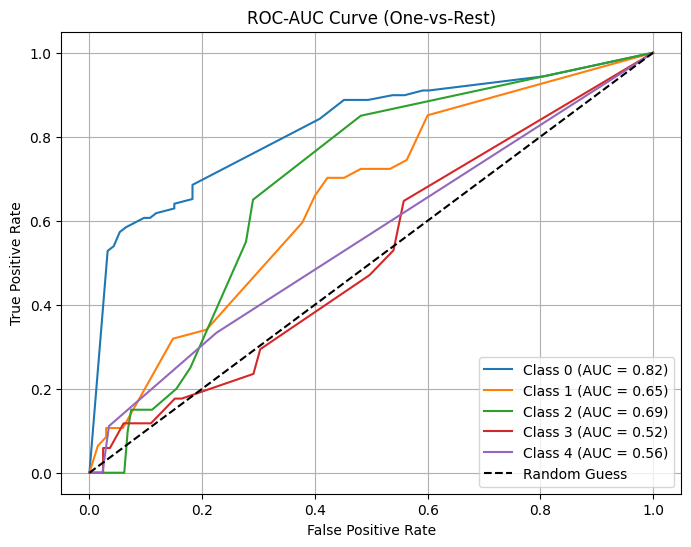

In [74]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarize the target
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)

# Get prediction probabilities
y_score = best_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(8,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--',label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

In [70]:

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})


In [71]:


# Sort in descending order
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                     Feature  Importance
4                     thalch    0.194807
7         cp_atypical angina    0.143340
5                    oldpeak    0.124308
0                        age    0.120840
1                   trestbps    0.110317
8             cp_non-anginal    0.094268
2                       chol    0.050721
10            restecg_normal    0.045222
16    thal_reversable defect    0.040069
15               thal_normal    0.023820
14           slope_upsloping    0.021439
3                        fbs    0.016162
9          cp_typical angina    0.014687
6                   sex_Male    0.000000
11  restecg_st-t abnormality    0.000000
12                   exang_1    0.000000
13                slope_flat    0.000000


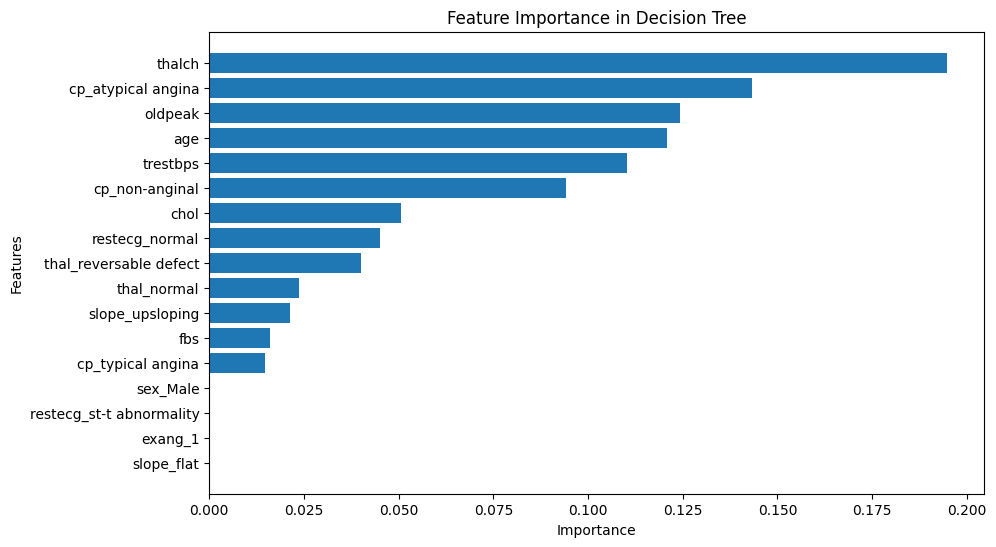

In [72]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Decision Tree")

plt.gca().invert_yaxis()

plt.show()

 Why do some features have zero importance?


A feature receives zero importance if the Decision Tree never uses it to split any node. This means other features provided enough information for prediction.

Feature importance analysis showed that thalach (maximum heart rate achieved) was the most influential predictor, followed by atypical angina, oldpeak, age, and resting blood pressure.

 Features such as sex_Male, exang_1, restecg_st-t abnormality, and slope_flat had zero importance, indicating that they were not used in the final Decision Tree for making classification decisions.

feature_names=X.columns    -->  # Displays feature names instead of X[0], X[1], ...

class_names=["No Disease", "Disease"] -->  # Displays class labels

filled=True       -->           # Colors the nodes

rounded=True      -->           # Rounded boxes

fontsize=8        -->           # Font size (optional)

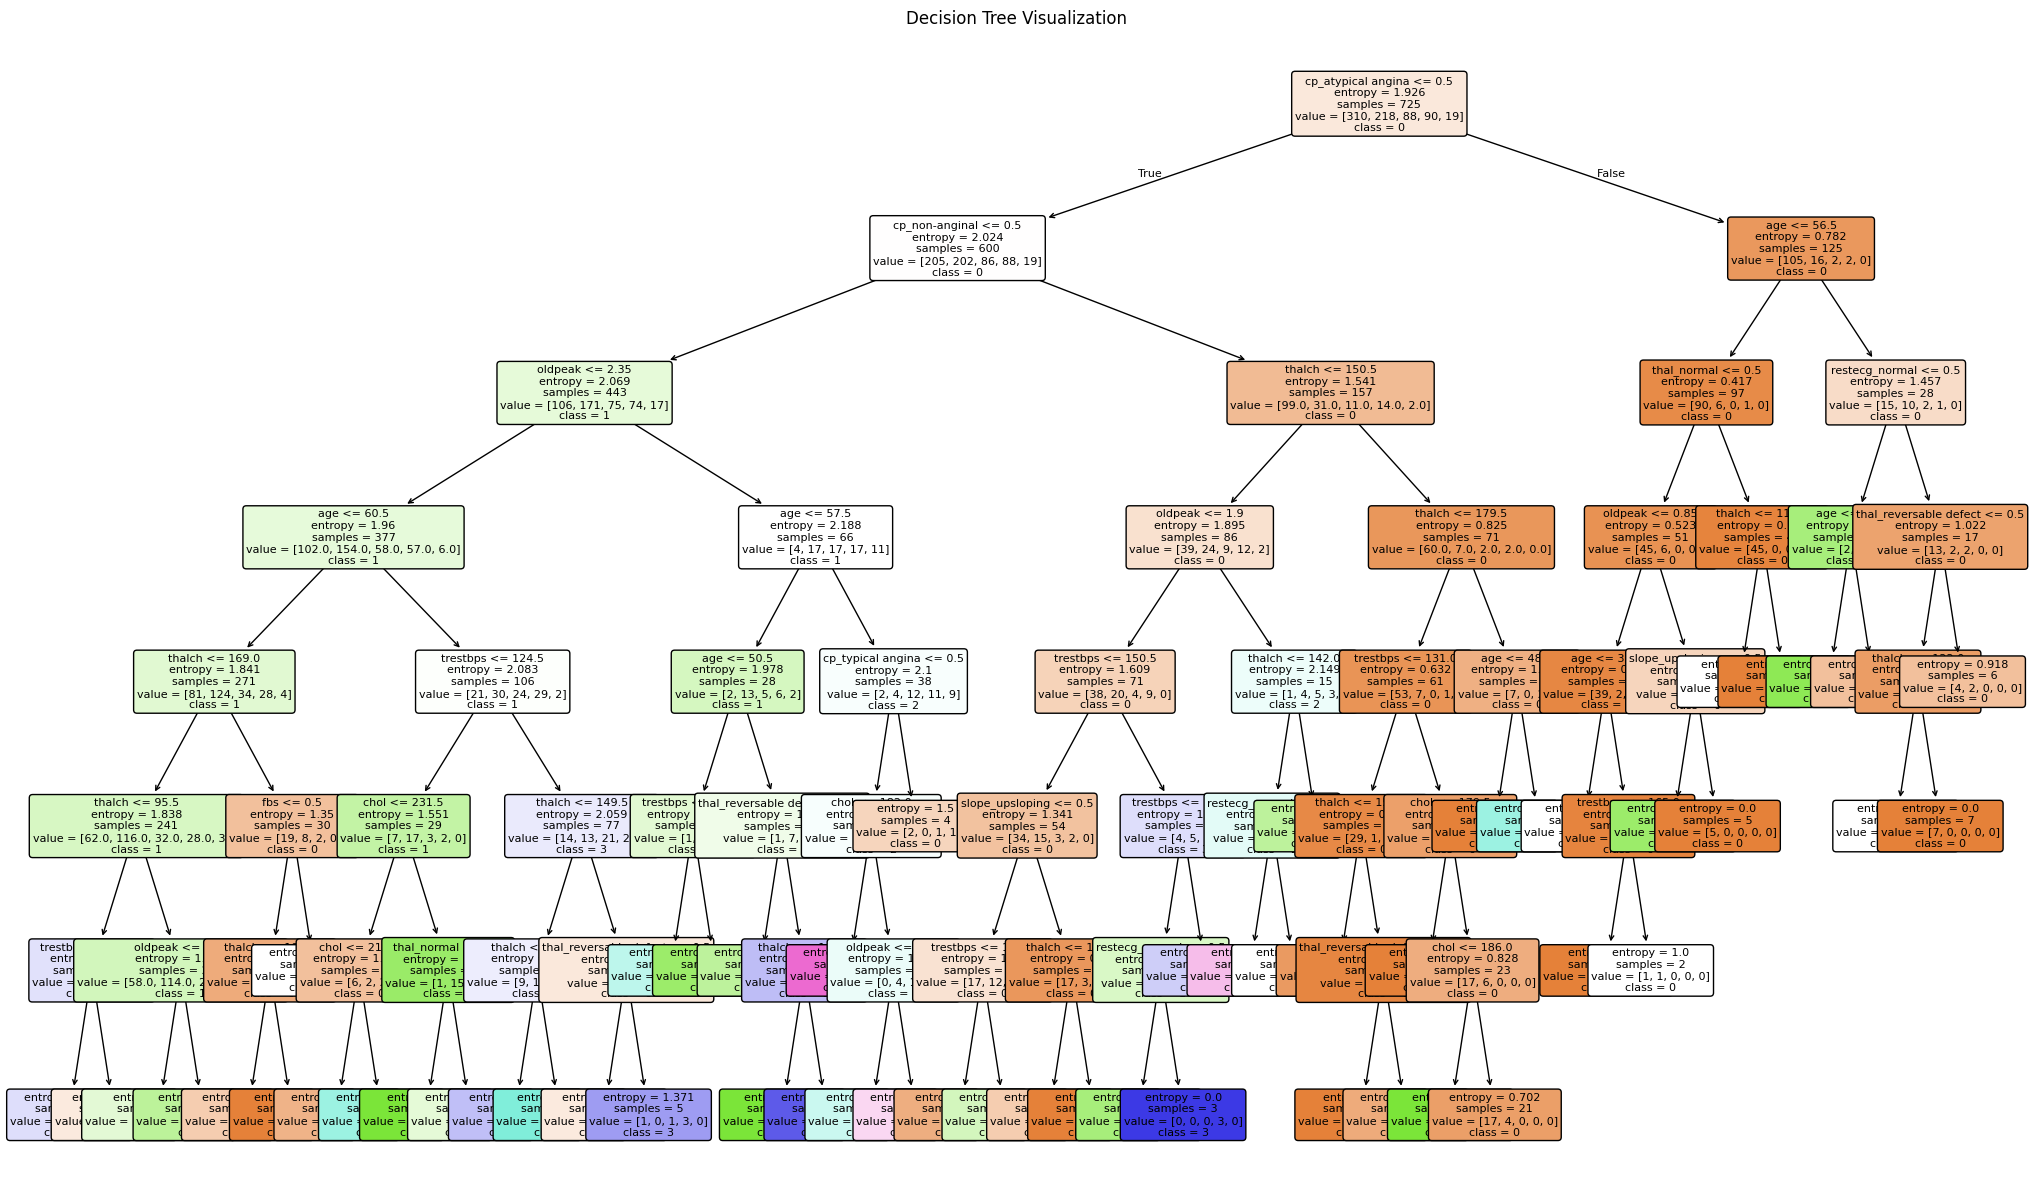

In [73]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(25,15))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=[str(i) for i in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.show()

#### conclusion

In this project, a Decision Tree Classifier was developed to predict heart disease severity using patient health data.

 The dataset was explored through Exploratory Data Analysis (EDA), cleaned by handling missing values and invalid entries, and categorical variables were encoded using one-hot encoding.

  The data was then split into training and testing sets before training a Decision Tree model.

The initial model achieved approximately 50% accuracy on the test dataset.

To improve performance, hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation. The optimal parameters were

 criterion='entropy',

  max_depth=7,
  
  min_samples_leaf=2, and
  
  min_samples_split=10,
  
  resulting in a test accuracy of approximately 50.55%.

Feature importance analysis showed that thalach (maximum heart rate achieved), atypical angina, oldpeak, age, and resting blood pressure were the most influential predictors.

The Decision Tree visualization further demonstrated how the model made predictions by applying a sequence of decision rules.


Although the tuned model showed stable performance, the overall accuracy indicates that predicting all five heart disease classes is challenging with a single Decision Tree.

Future improvements could include trying ensemble methods such as Random Forest, XGBoost, or Gradient Boosting, as well as addressing class imbalance and exploring additional feature engineering techniques.